Notebook to test methane forcing by OH from the GFDL model. 

Test:
1. perturbation form of methane vs. changing the lifetime of methane directly
2. how to parameterize the exogenous forcing by OH (aka the scaling factor to relate v/v to Tg methane/yr (ppb methane/yr))
3. (maybe) tropical vs. global OH

Units:
OH is given in v/v in the GFDL model. For ease, I will convert the reaction rate from [Burkholder et al.](https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf) from cm<sup>-3</sup> molec<sup>-1</sup> s<sup>-1</sup> to v/v year<sup>-1</sup>, from which either the lifetime deviations or the methane tendency can be calculated. This will require an assumption of mean temperature at which the reaction occurs.


In [22]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant
)
from methane_noise_forcing.core import FirnFilter
plt.rcParams.update(matplotlib_rcparams)

In [23]:
## figure settings
fig_width = fig_width_options["two_column_large"]  # inches
ax_height = 1.5  # inches

In [24]:
# read in OH forcing data
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="config", overrides=["+firn_kernel=firn_model_wais"])

ds = xr.open_dataset(Path(cfg.paths.data_dir) / "oh_forcing" / "oh_forcing.nc")
# extract OH
da_oh_mean = ds["OH"].mean(dim="time")
da_oh_anomaly = ds["OH"] - da_oh_mean
da_oh_anomaly_fraction = da_oh_anomaly / da_oh_mean

In [25]:
# import firn filter for later
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)

In [26]:
# choose appropriate selection
column = "free_trop"
region = "tropical"

oh_mean = da_oh_mean.sel(region=region, column=column).values.item()
oh_anomaly = da_oh_anomaly.sel(region=region, column=column)
oh_anomaly_fraction = da_oh_anomaly_fraction.sel(region=region, column=column)

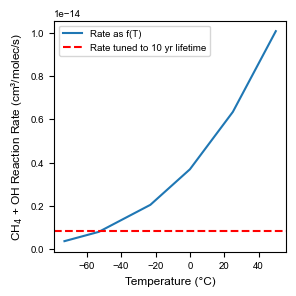

In [27]:
## tune reaction rate such that mean lifetime of ch4 is 10 years
mean_lifetime = 10 # years

k_ch4_oh = 1 / mean_lifetime / oh_mean # (mol rxn / mol air)^-1 yr^-1

## compare rate constant with empirical
## placeholder for now: Alex's pre-computed conversion with number density of air
#  need to eventually change to use temperature and pressure to scale for sensitivity
n_air = 2.69e19 # Rough: number density of air ((molec air / cm3) / mol air)
s_per_year = 24 * 60 * 60 * 365.25 # s/yr

k_converted = k_ch4_oh / s_per_year / n_air # cm3/molec/s

def k_ch4_oh_func(temp):
    """
    Reaction rate of CH4 + OH

    temperature in K, rate in cm3/molec/s
    """
    k = 2.8e-14 * (temp**0.667) * np.exp(-1575 / temp)
    return k

temperatures = np.array([200, 220, 250, 273, 298, 323])  # K
k_as_f_of_temps = k_ch4_oh_func(temperatures)  # cm3/molec/s

fig, ax = plt.subplots(figsize=(3,3))

ax.plot(temperatures - 273, k_as_f_of_temps, label="Rate as f(T)")
ax.axhline(k_converted, color='r', linestyle='--', label=f"Rate tuned to {mean_lifetime} yr lifetime")

ax.set_ylabel("CH$_4$ + OH Reaction Rate (cm³/molec/s)")
ax.set_xlabel("Temperature (°C)")
ax.legend()

# test class (will be implemented as actual class)

In [28]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Optional, Tuple, Union, Literal
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

# ------------------------------------------
# Types
TimeSeries = Tuple[np.ndarray, np.ndarray]
ScalarOrCallableOrSeries = Union[float, Callable[[float], float], TimeSeries]
# ------------------------------------------

@dataclass
class OneBoxResult:
    t: np.ndarray
    C: np.ndarray
    success: bool
    message: str

def _as_timefunc(
    spec: ScalarOrCallableOrSeries,
    *,
    name: str,
    kind: Literal["linear", "nearest", "cubic", "previous"] = "cubic",
    extrapolate: bool = False,
) -> Callable[[float], float]:
    """
    Turn a scalar, callable, or (t, y) pair into a function of time.
    - Scalars -> constant function
    - Callables -> returned as-is
    - (t, y) -> interp1d (with optional step via 'previous')
    """
    if np.isscalar(spec):
        val = float(spec)
        return lambda t: val
    if callable(spec):
        return spec
    # (t, y) pair
    if not (isinstance(spec, (tuple, list)) and len(spec) == 2):
        raise TypeError(f"{name} must be a scalar, callable, or (t, y) pair.")
    t, y = spec
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if t.ndim != 1 or y.ndim != 1 or t.size != y.size or t.size < 2:
        raise ValueError(f"{name}: (t, y) must be 1D and of equal length >= 2.")
    order = np.argsort(t)
    t = t[order]
    y = y[order]
    if kind == "previous":
        # left-hold step function
        def f(tq):
            tq = np.asarray(tq)
            idx = np.searchsorted(t, tq, side="right") - 1
            if extrapolate:
                idx = np.clip(idx, 0, len(t) - 1)
            else:
                idx = np.where((tq < t[0]) | (tq > t[-1]), -1, idx)
            out = np.where(idx == -1, np.nan, y[idx])
            return out
        return lambda tt: float(f(tt))
    fill = "extrapolate" if extrapolate else (y[0], y[-1])
    f = interp1d(t, y, kind="linear" if kind == "previous" else kind,
                 bounds_error=False, fill_value=fill, assume_sorted=True)
    return lambda tt: float(f(tt))

def solve_ch4_onebox(
    *,
    t_eval: np.ndarray,
    C0: float,
    S: ScalarOrCallableOrSeries,
    # Choose ONE of the following ways to specify λ(t):
    lam: Optional[ScalarOrCallableOrSeries] = None,     # λ(t) directly
    tau: Optional[ScalarOrCallableOrSeries] = None,     # lifetime τ(t) -> λ(t)=1/τ(t)
    k: Optional[float] = None,                          # with OH(t): λ(t)=k*OH(t)
    OH: Optional[ScalarOrCallableOrSeries] = None,
    # Interpolation & solver options
    s_kind: Literal["linear", "nearest", "cubic", "previous"] = "cubic",
    l_kind: Literal["linear", "nearest", "cubic", "previous"] = "cubic",
    extrapolate: bool = False,
    method: str = "LSODA",
    enforce_nonnegative: bool = False,
    **kwargs
) -> OneBoxResult:
    """
    Unified solver for dC/dt = S(t) - λ(t) C(t)

    Supply λ(t) via exactly ONE of:
      1) lam               -> scalar/callable/(t, y)
      2) tau               -> λ(t) = 1 / τ(t)
      3) k AND OH          -> λ(t) = k * OH(t)

    S can be scalar, callable, or (t, y).

    Units:
      - Pick a time unit (e.g., years) for t_eval and all time series.
      - If C is ppb, then:
          S in ppb / time
          λ in 1 / time  (so k*OH or 1/τ must evaluate to 1/time)
    """
    t_eval = np.asarray(t_eval, dtype=float)
    if t_eval.ndim != 1 or t_eval.size < 2 or not np.all(np.diff(t_eval) > 0):
        raise ValueError("t_eval must be 1D, strictly increasing, length >= 2.")

    # Build S(t)
    S_of_t = _as_timefunc(S, name="S", kind=s_kind, extrapolate=extrapolate)

    # Build λ(t)
    provided = sum([lam is not None, tau is not None, (k is not None and OH is not None)])
    if provided != 1:
        raise ValueError("Specify exactly ONE of lam, tau, or (k and OH).")

    if lam is not None:
        lam_of_t = _as_timefunc(lam, name="lam", kind=l_kind, extrapolate=extrapolate)
    elif tau is not None:
        tau_of_t = _as_timefunc(tau, name="tau", kind=l_kind, extrapolate=extrapolate)
        lam_of_t = lambda t: 1.0 / tau_of_t(t)
    else:
        if not np.isscalar(k):
            raise TypeError("k must be a scalar when using (k, OH).")
        OH_of_t = _as_timefunc(OH, name="OH", kind=l_kind, extrapolate=extrapolate)
        lam_of_t = lambda t: k * OH_of_t(t)

    # RHS
    def rhs(t, C):
        return S_of_t(t) - lam_of_t(t) * C

    sol = solve_ivp(
        rhs,
        t_span=(t_eval[0], t_eval[-1]),
        y0=[C0],
        t_eval=t_eval,
        method=method,
        **kwargs
    )

    C = sol.y[0]
    if enforce_nonnegative:
        C = np.maximum(C, 0.0)

    return OneBoxResult(t=sol.t, C=C, success=sol.success, message=sol.message)

# -----------------------------
# Convenience wrapper: anomaly (lifetime) mode
def solve_ch4_anomaly_lifetime(
    t_eval: np.ndarray,
    C0_anom: float,
    S_anom: ScalarOrCallableOrSeries,   # source-sink imbalance anomaly (ppb/time)
    tau: ScalarOrCallableOrSeries = 10.0,   # years by default
    **kwargs,
) -> OneBoxResult:
    """
    dC'/dt = S'(t) - (1/τ) C'
    For anomalies, negatives are physically meaningful – we do not clip by default.
    """
    return solve_ch4_onebox(
        t_eval=t_eval,
        C0=C0_anom,
        S=S_anom,
        tau=tau,
        enforce_nonnegative=False,
        **kwargs,
    )


## test class with perturbation experiments
Tau and k and OH with lifetime of 10 years

Text(0, 0.5, 'Methane concentration (ppb)')

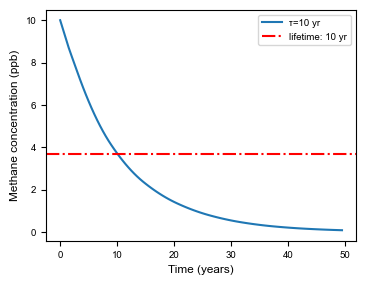

In [29]:
## test with tau directly
tau = 10 # years
C0 = 10 # ppb
t_eval = np.arange(0, 50, 0.5) # years

result = solve_ch4_onebox(
    t_eval=t_eval,
    C0=C0 * 1e-9,
    S=0,  # ppb/year
    tau=tau,
)

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(result.t, result.C * 1e9, label=f"τ={tau} yr")
ax.axhline(np.exp(-1) * C0, color='r', ls='-.', label=f"lifetime: {tau} yr")

ax.legend()
ax.set_xlabel("Time (years)")
ax.set_ylabel("Methane concentration (ppb)")

Text(0, 0.5, 'Methane concentration (ppb)')

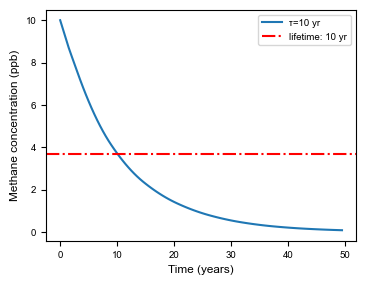

In [30]:
## test with k and OH
C0 = 10 # ppb
t_eval = np.arange(0, 50, 0.5) # years

result = solve_ch4_onebox(
    t_eval=t_eval,
    C0=C0 * 1e-9,
    S=0,  # ppb/year
    k=k_ch4_oh, # (mol rxn / mol air)^-1 yr^-1
    OH=oh_mean, # (mol rxn / mol air)
)

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(result.t, result.C * 1e9, label=f"τ={tau} yr")
ax.axhline(np.exp(-1) * C0, color='r', ls='-.', label=f"lifetime: {tau} yr")

ax.legend()
ax.set_xlabel("Time (years)")
ax.set_ylabel("Methane concentration (ppb)")

Text(0, 0.5, 'Methane concentration (ppb)')

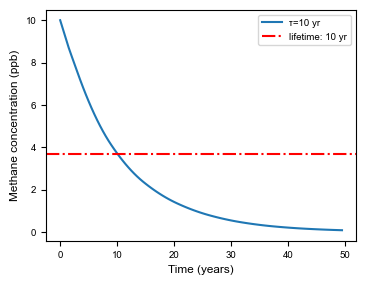

In [31]:
## finally, test with perturbation form
C0 = 10 # ppb
t_eval = np.arange(0, 50, 0.5) # years

result = solve_ch4_anomaly_lifetime(
    t_eval=t_eval,
    C0_anom=C0 * 1e-9,
    S_anom=0,  # ppb/year
    tau=10, # years
)

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(result.t, result.C * 1e9, label=f"τ={tau} yr")
ax.axhline(np.exp(-1) * C0, color='r', ls='-.', label=f"lifetime: {tau} yr")

ax.legend()
ax.set_xlabel("Time (years)")
ax.set_ylabel("Methane concentration (ppb)")

# full mass balance form

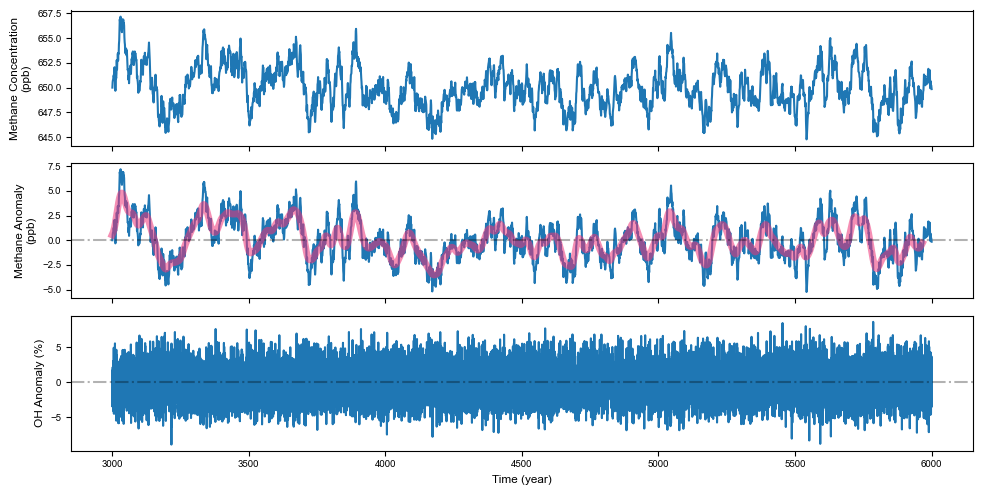

In [32]:
ch4_mean = 650 # ppb
# solve for S_ch4 in terms of ppb / year
S_ch4 = ch4_mean * k_ch4_oh * oh_mean # ppb / year
OH_over_time = (oh_anomaly.time.values, oh_anomaly.values + oh_mean)
t_eval = np.arange(3001, 6002, 1) # years
instantaneous_offset = 35 # years

result_full_mb = solve_ch4_onebox( # all units are mol/mol
    t_eval=t_eval,
    C0=ch4_mean * 1e-9,
    S=S_ch4 * 1e-9,  
    k=k_ch4_oh, # (mol rxn / mol air)^-1 yr^-1
    OH=OH_over_time, # (mol rxn / mol air)
    max_step=0.1, # year
)

## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(3, 1, figsize=(fig_width*1.4, 5), sharex=True)

# top plot: full methane concentration
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

axs[0].plot(result_full_mb.t[time_mask], result_full_mb.C[time_mask] * 1e9, label="Methane Concentration")
axs[0].set_ylabel("Methane Concentration\n(ppb)")

# middle plot: methane anomaly
methane_anomaly_plot = result_full_mb.C - ch4_mean * 1e-9
methane_anomaly_plot_smoothed = firn_filter.apply(
    methane_anomaly_plot,
    dt_series=np.mean(np.diff(t_eval))
)
axs[1].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_full_mb.t >= time_min_plot + instantaneous_offset) & (result_full_mb.t <= time_max_plot + instantaneous_offset)
axs[1].plot(result_full_mb.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[2].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[2].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[2].set_ylabel("OH Anomaly (%)")
axs[2].set_xlabel("Time (year)")

plt.tight_layout()

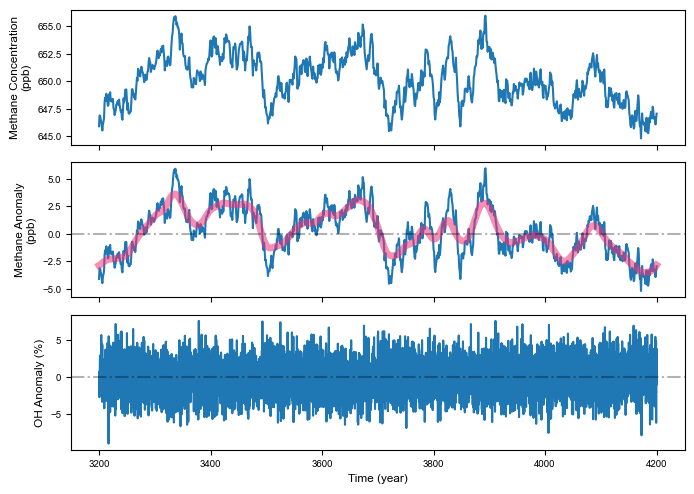

In [33]:
# zoomed in plot
time_min_plot = 3200
time_max_plot = 4200
fig, axs = plt.subplots(3, 1, figsize=(fig_width, 5), sharex=True)

# top plot: full methane concentration
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

axs[0].plot(result_full_mb.t[time_mask], result_full_mb.C[time_mask] * 1e9, label="Methane Concentration")
axs[0].set_ylabel("Methane Concentration\n(ppb)")

# middle plot: methane anomaly
methane_anomaly_plot = result_full_mb.C - ch4_mean * 1e-9
methane_anomaly_plot_smoothed = firn_filter.apply(
    methane_anomaly_plot,
    dt_series=np.mean(np.diff(t_eval))
)
axs[1].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_full_mb.t >= time_min_plot + instantaneous_offset) & (result_full_mb.t <= time_max_plot + instantaneous_offset)
axs[1].plot(result_full_mb.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[2].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[2].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[2].set_ylabel("OH Anomaly (%)")
axs[2].set_xlabel("Time (year)")

plt.tight_layout()

# perturbation form

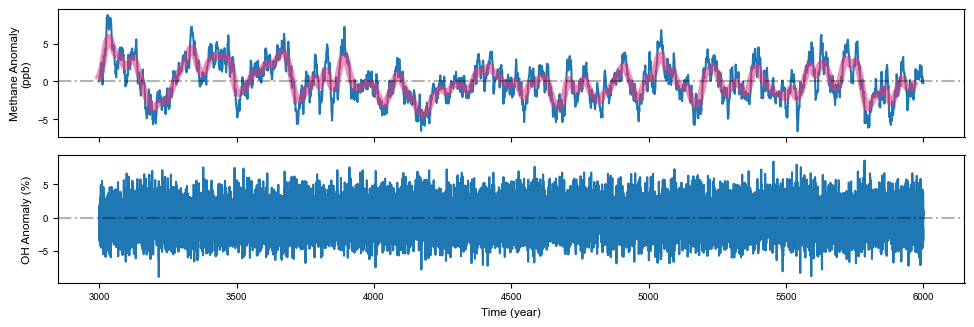

In [45]:
ch4_mean = 800 # ppb
# solve for source/sink anomaly in terms of ppb/year
rate_mean = ch4_mean * k_ch4_oh * oh_mean # ppb / year
S_anom = -1 * rate_mean * (oh_anomaly_fraction) # ppb / year
t_eval = np.arange(3001, 6002, 1) # years
instantaneous_offset = 35 # years 

result_anomaly = solve_ch4_anomaly_lifetime(
    t_eval=t_eval,
    C0_anom=0,
    S_anom=(S_anom.time.values, S_anom.values * 1e-9),
    tau=mean_lifetime,
    max_step=0.1, # year
)

## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(2, 1, figsize=(fig_width*1.4, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
methane_anomaly_plot_smoothed = firn_filter.apply(
    result_anomaly.C,
    dt_series=np.mean(np.diff(t_eval))
)
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_anomaly.t >= time_min_plot + instantaneous_offset) & (result_anomaly.t <= time_max_plot + instantaneous_offset)
axs[0].plot(result_anomaly.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Anomaly (%)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()

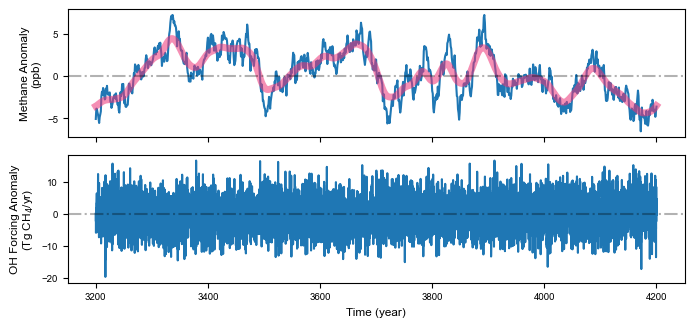

In [46]:
## zoomed in plot
time_min_plot = 3200
time_max_plot = 4200
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
methane_anomaly_plot_smoothed = firn_filter.apply(
    result_anomaly.C,
    dt_series=np.mean(np.diff(t_eval))
)
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            label="Methane Anomaly (ppb)")
# offset smoothed series by 35 years
mask_smoothed = (result_anomaly.t >= time_min_plot + instantaneous_offset) & (result_anomaly.t <= time_max_plot + instantaneous_offset)
axs[0].plot(result_anomaly.t[mask_smoothed] - instantaneous_offset, 
            methane_anomaly_plot_smoothed[mask_smoothed] * 1e9, 
            lw=5,
            color=colors_vibrant["magenta"],
            alpha=0.55,
            label="Methane Anomaly (ppb)")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(S_anom.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            S_anom.sel(time=slice(time_min_plot, time_max_plot)).values * -2.75, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Forcing Anomaly\n(Tg CH$_4$/yr)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()

## compare full model to perturbation form

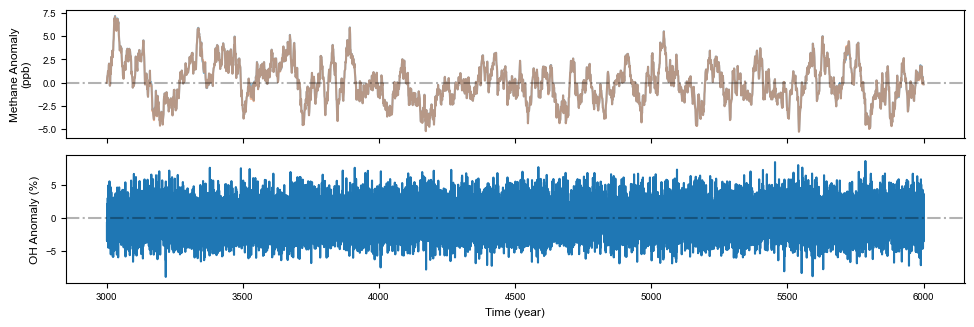

In [36]:
## plot
time_min_plot = 3000
time_max_plot = 6000
fig, axs = plt.subplots(2, 1, figsize=(fig_width*1.4, 10/3), sharex=True)
time_mask = (result_full_mb.t >= time_min_plot) & (result_full_mb.t <= time_max_plot)

# top plot: methane anomaly
axs[0].plot(result_full_mb.t[time_mask], 
            methane_anomaly_plot[time_mask] * 1e9, 
            color=colors_vibrant["blue"],
            alpha=0.5,
            label="full")
axs[0].plot(result_anomaly.t[time_mask], 
            result_anomaly.C[time_mask] * 1e9, 
            color=colors_vibrant["orange"],
            alpha=0.5,
            label="perturbation")
axs[0].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[0].set_ylabel("Methane Anomaly\n(ppb)")

# bottom plot: OH forcing
axs[1].plot(oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).time.values, 
            oh_anomaly_fraction.sel(time=slice(time_min_plot, time_max_plot)).values * 100, 
            label="OH Forcing Anomaly (%)")
axs[1].axhline(0, color="k", linestyle="-.", alpha=0.3)
axs[1].set_ylabel("OH Anomaly (%)")
axs[1].set_xlabel("Time (year)")

plt.tight_layout()